In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [51]:
# Pengaturan tampilan agar semua kolom terlihat
pd.set_option('display.max_columns', None)

# List untuk menyimpan hasil metrik
model_comparison = []

# Fungsi Evaluasi Model yang Disesuaikan
def evaluate_model(y_true, y_pred, model_name):
    """Fungsi untuk menampilkan Confusion Matrix dan Classification Report."""
    print(f"--- Hasil Evaluasi: {model_name} ---")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Sehat (0)', 'Bangkrut (1)'],
                yticklabels=['Sehat (0)', 'Bangkrut (1)'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Aktual')
    plt.xlabel('Prediksi')
    plt.savefig(f'confusion_matrix_{model_name.replace(" ", "_")}.png')
    plt.close() # Tutup plot agar tidak tampil di notebook

    # Classification Report
    print(classification_report(y_true, y_pred, target_names=['Sehat', 'Bangkrut']))

    # Mengembalikan confusion matrix dan classification report dalam bentuk dictionary
    return cm, classification_report(y_true, y_pred, output_dict=True)

# Ganti 'data-bank.csv' dengan nama file yang sesuai
file_path = 'data-bank.csv'

In [52]:
# Data Cleaning
const_cols = df.columns[df.nunique() <= 1]
if len(const_cols) > 0:
    df.drop(columns=const_cols, inplace=True)


--- Visualisasi EDA: Hubungan Variabel Net worth/Assets dengan Kebangkrutan ---


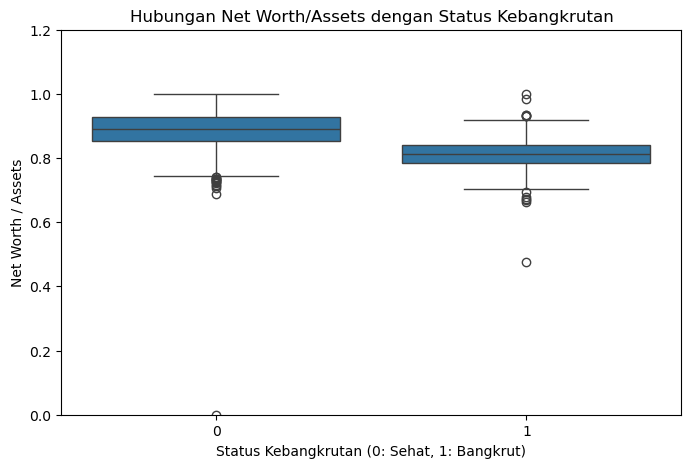

In [53]:
print("\n--- Visualisasi EDA: Hubungan Variabel Net worth/Assets dengan Kebangkrutan ---")

plt.figure(figsize=(8, 5))

# PERBAIKAN: Menggunakan ' Net worth/Assets' (dengan spasi di depan)
sns.boxplot(x='Bankrupt?', y=' Net worth/Assets', data=df)

# Atur batas Y-axis agar visualisasi lebih fokus pada perbedaan
plt.ylim(0, 1.2) 

plt.title('Hubungan Net Worth/Assets dengan Status Kebangkrutan')
plt.xlabel('Status Kebangkrutan (0: Sehat, 1: Bangkrut)')
plt.ylabel('Net Worth / Assets')
plt.show()

In [54]:
df = pd.read_csv(file_path)

# Data Understanding & Cleaning
# Menghapus kolom yang memiliki varian nol (hanya berisi satu nilai)
const_cols = df.columns[df.nunique() <= 1]
if len(const_cols) > 0:
    df.drop(columns=const_cols, inplace=True)

# Tentukan fitur (X) dan target (y)
X = df.drop('Bankrupt?', axis=1) # Menggunakan nama kolom asli
y = df['Bankrupt?']            # Menggunakan nama kolom asli

# Pembagian data Training dan Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Penskalaan (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Penanganan Data Imbalance Menggunakan SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled_df, y_train)
print("Data Preparation Selesai. Distribusi Kelas Training setelah SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Data Preparation Selesai. Distribusi Kelas Training setelah SMOTE:
Bankrupt?
0    4619
1    4619
Name: count, dtype: int64


In [55]:
def evaluate_model(y_true, y_pred, model_name):
    """Fungsi untuk menampilkan Confusion Matrix dan Classification Report."""
    print(f"--- Hasil Evaluasi: {model_name} ---")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Sehat (0)', 'Bangkrut (1)'],
                yticklabels=['Sehat (0)', 'Bangkrut (1)'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Aktual')
    plt.xlabel('Prediksi')
    plt.show()

    # Classification Report
    print(classification_report(y_true, y_pred, target_names=['Sehat', 'Bangkrut']))

    # AUC-ROC Score
    try:
        y_pred_proba = model.predict_proba(X_test_scaled_df)[:, 1]
        roc_auc = roc_auc_score(y_true, y_pred_proba)
        print(f"AUC-ROC Score: {roc_auc:.4f}")
    except:
        # Untuk ANN, kita perlu penanganan yang berbeda
        pass
    print("-" * 50)
    return cm, classification_report(y_true, y_pred, output_dict=True)

# List untuk menyimpan hasil metrik
model_comparison = []

--- Hasil Evaluasi: Decision Tree ---


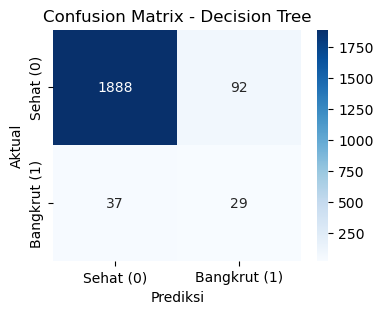

              precision    recall  f1-score   support

       Sehat       0.98      0.95      0.97      1980
    Bangkrut       0.24      0.44      0.31        66

    accuracy                           0.94      2046
   macro avg       0.61      0.70      0.64      2046
weighted avg       0.96      0.94      0.95      2046

--------------------------------------------------
AUC-ROC Score: 0.6965
--------------------------------------------------


In [56]:
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train_smote, y_train_smote)
y_pred_dt = model_dt.predict(X_test_scaled_df)

# EVALUASI
cm_dt, report_dt = evaluate_model(y_test, y_pred_dt, "Decision Tree")
roc_auc_dt = roc_auc_score(y_test, model_dt.predict_proba(X_test_scaled_df)[:, 1])
print(f"AUC-ROC Score: {roc_auc_dt:.4f}")
print("-" * 50)

# Simpan hasil (Menggunakan key '1' yang benar)
model_comparison.append({
    'Model': 'Decision Tree',
    'Recall (Bangkrut)': report_dt['1']['recall'],
    'F1-Score (Bangkrut)': report_dt['1']['f1-score'],
    'AUC-ROC': roc_auc_dt
})

--- Hasil Evaluasi: Random Forest ---


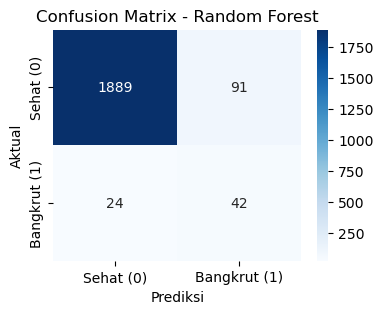

              precision    recall  f1-score   support

       Sehat       0.99      0.95      0.97      1980
    Bangkrut       0.32      0.64      0.42        66

    accuracy                           0.94      2046
   macro avg       0.65      0.80      0.70      2046
weighted avg       0.97      0.94      0.95      2046

--------------------------------------------------
AUC-ROC Score: 0.9428
--------------------------------------------------


In [57]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
model_rf.fit(X_train_smote, y_train_smote)
y_pred_rf = model_rf.predict(X_test_scaled_df)

# EVALUASI
cm_rf, report_rf = evaluate_model(y_test, y_pred_rf, "Random Forest")
roc_auc_rf = roc_auc_score(y_test, model_rf.predict_proba(X_test_scaled_df)[:, 1])
print(f"AUC-ROC Score: {roc_auc_rf:.4f}")
print("-" * 50)

# Simpan hasil (Menggunakan key '1' yang benar)
model_comparison.append({
    'Model': 'Random Forest',
    'Recall (Bangkrut)': report_rf['1']['recall'],
    'F1-Score (Bangkrut)': report_rf['1']['f1-score'],
    'AUC-ROC': roc_auc_rf
})

C:\Users\USER\miniconda3\envs\ai_env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- Hasil Evaluasi: ANN ---


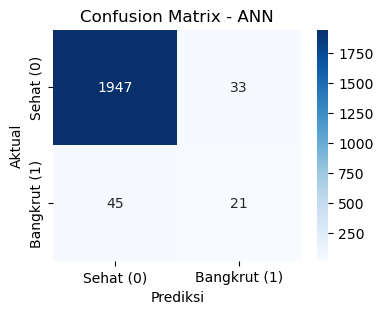

              precision    recall  f1-score   support

       Sehat       0.98      0.98      0.98      1980
    Bangkrut       0.39      0.32      0.35        66

    accuracy                           0.96      2046
   macro avg       0.68      0.65      0.67      2046
weighted avg       0.96      0.96      0.96      2046

--------------------------------------------------
AUC-ROC Score: 0.8523
--------------------------------------------------


In [58]:
# Pembuatan Model ANN
model_ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_smote.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Pelatihan Model (verbose=0 agar tidak terlalu banyak output)
model_ann.fit(X_train_smote, y_train_smote, epochs=20, batch_size=32, verbose=0, validation_split=0.2)
y_pred_proba_ann = model_ann.predict(X_test_scaled_df, verbose=0)
y_pred_ann = (y_pred_proba_ann > 0.5).astype(int)

# EVALUASI
cm_ann, report_ann = evaluate_model(y_test, y_pred_ann, "ANN")
roc_auc_ann = roc_auc_score(y_test, y_pred_proba_ann)
print(f"AUC-ROC Score: {roc_auc_ann:.4f}")
print("-" * 50)

# Simpan hasil (Menggunakan key '1' yang benar)
model_comparison.append({
    'Model': 'ANN',
    'Recall (Bangkrut)': report_ann['1']['recall'],
    'F1-Score (Bangkrut)': report_ann['1']['f1-score'],
    'AUC-ROC': roc_auc_ann
})

In [59]:
df_comparison = pd.DataFrame(model_comparison)
df_comparison = df_comparison.sort_values(by='Recall (Bangkrut)', ascending=False)

print("\n### Perbandingan Performa Model (Fokus pada Recall Kelas Bangkrut) ###")
print(df_comparison.round(4))

# Penentuan Algoritma Terbaik
best_model_name = df_comparison.iloc[0]['Model']

print(f"\nKesimpulan: Algoritma yang paling sesuai adalah **{best_model_name}**.")
print("Alasannya: Algoritma ini memberikan nilai **Recall** tertinggi pada kelas 'Bangkrut', yang berarti ia paling efektif dalam meminimalkan False Negatives (bank bangkrut diprediksi sehat).")


### Perbandingan Performa Model (Fokus pada Recall Kelas Bangkrut) ###
           Model  Recall (Bangkrut)  F1-Score (Bangkrut)  AUC-ROC
1  Random Forest             0.6364               0.4221   0.9428
0  Decision Tree             0.4394               0.3102   0.6965
2            ANN             0.3182               0.3500   0.8523

Kesimpulan: Algoritma yang paling sesuai adalah **Random Forest**.
Alasannya: Algoritma ini memberikan nilai **Recall** tertinggi pada kelas 'Bangkrut', yang berarti ia paling efektif dalam meminimalkan False Negatives (bank bangkrut diprediksi sehat).



### 5 Variabel Paling Mempengaruhi Kebangkrutan Bank (Menurut Random Forest) ###
                                     Feature  Importance
9       Continuous interest rate (after tax)    0.086191
18   Persistent EPS in the Last Four Seasons    0.061191
7                After-tax net Interest Rate    0.049752
85                Net Income to Total Assets    0.040521
39                      Borrowing dependency    0.040518


C:\Users\USER\AppData\Local\Temp\ipykernel_6148\1812330069.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_5_features, palette='viridis')


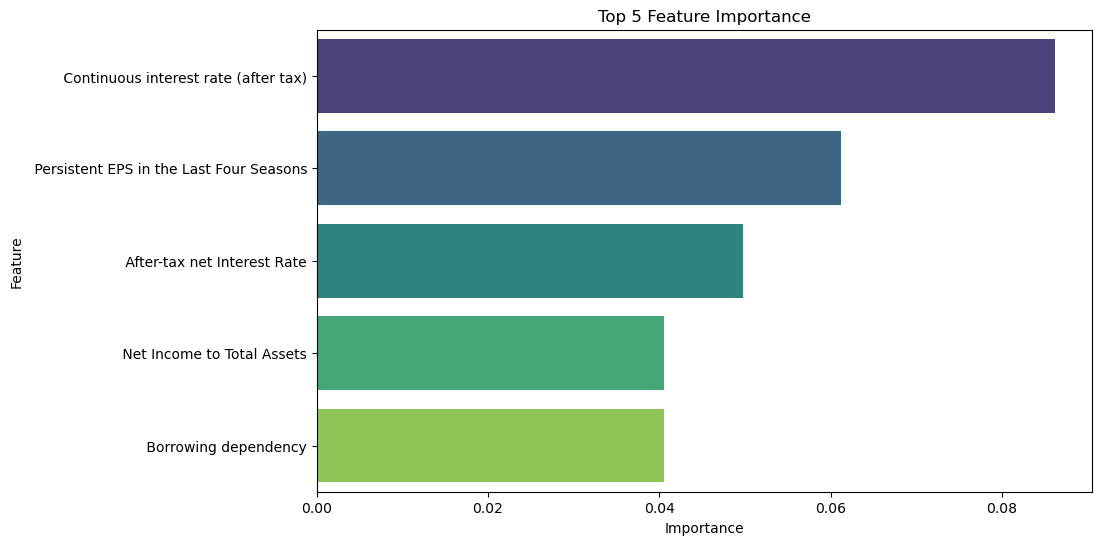

In [60]:
# Mendapatkan Feature Importance dari Random Forest
feature_importances = model_rf.feature_importances_
features = X_train_scaled_df.columns
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
})

# Urutkan berdasarkan Importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 5 Variabel Paling Mempengaruhi Kebangkrutan
top_5_features = importance_df.head(5)

print("\n### 5 Variabel Paling Mempengaruhi Kebangkrutan Bank (Menurut Random Forest) ###")
print(top_5_features)

# Visualisasi Top 5
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_5_features, palette='viridis')
plt.title('Top 5 Feature Importance')
plt.show()